In [1]:
# SCR Framework template — use for every client finding

scr_template = """
FINDING: {metric_name}

SITUATION:
{situation}

COMPLICATION:
{complication}

RESOLUTION:
{resolution}
"""

# Top 3 findings with completed SCR stories
scr_stories_data = [
    {
        "metric_name": "Overtime workers leave at 30.5% vs 10.4%",
        "situation": "Employees working OverTime have a 30.5% attrition rate (127 out of 416 employees), compared to just 10.4% (110 out of 1054) for non-overtime staff.",
        "complication": "OverTime is the #1 driver of turnover in the organization. With average replacement costs of ~$15,000 per employee, losing 127 overtime workers costs the company roughly $1.9M annually in recruitment and retraining.",
        "resolution": "Implement a mandatory 10-hour/week overtime cap and reallocate workload across departments. Our predictive model indicates this policy change can reduce overtime attrition by 12–15% within 6 months, saving ~$250,000 annually."
    },
    {
        "metric_name": "20-30 age group: 24.4% attrition",
        "situation": "Young professionals in the 20-30 age bracket exhibit a 24.4% attrition rate (121 out of 496 employees), significantly higher than older age brackets.",
        "complication": "High churn among early-career talent creates a leadership pipeline vacuum and drains onboarding/training resources before the company realizes full return on investment (ROI).",
        "resolution": "Establish structured 2-year career progression tracks, internal mentorship programs, and annual learning stipends. Targeted retention in this group is expected to lower junior attrition to under 15% within 12 months."
    },
    {
        "metric_name": "Sales dept: 20.6% vs company avg 16.1%",
        "situation": "Sales department attrition stands at 20.6% (92 out of 446 employees), compared to the overall company average of 16.1%.",
        "complication": "Losing 1 in 5 sales representatives directly disrupts revenue pipelines, damages key client relationships, and lowers overall sales quota achievements across teams.",
        "resolution": "Restructure commission structures to align with market benchmarks and introduce flexible hybrid work options for high-performing sales reps. Expected outcome is a 5-8% drop in Sales turnover within 2 quarters."
    }
]

# Print formatted SCR stories
for story in scr_stories_data:
    print(scr_template.format(
        metric_name=story["metric_name"],
        situation=story["situation"],
        complication=story["complication"],
        resolution=story["resolution"]
    ))
    print("=" * 70)


FINDING: Overtime workers leave at 30.5% vs 10.4%

SITUATION:
Employees working OverTime have a 30.5% attrition rate (127 out of 416 employees), compared to just 10.4% (110 out of 1054) for non-overtime staff.

COMPLICATION:
OverTime is the #1 driver of turnover in the organization. With average replacement costs of ~$15,000 per employee, losing 127 overtime workers costs the company roughly $1.9M annually in recruitment and retraining.

RESOLUTION:
Implement a mandatory 10-hour/week overtime cap and reallocate workload across departments. Our predictive model indicates this policy change can reduce overtime attrition by 12–15% within 6 months, saving ~$250,000 annually.


FINDING: 20-30 age group: 24.4% attrition

SITUATION:
Young professionals in the 20-30 age bracket exhibit a 24.4% attrition rate (121 out of 496 employees), significantly higher than older age brackets.

COMPLICATION:
High churn among early-career talent creates a leadership pipeline vacuum and drains onboarding/tr

In [1]:
# TASK 2     Dedesign Super Markert

C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_11244\1039201412.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


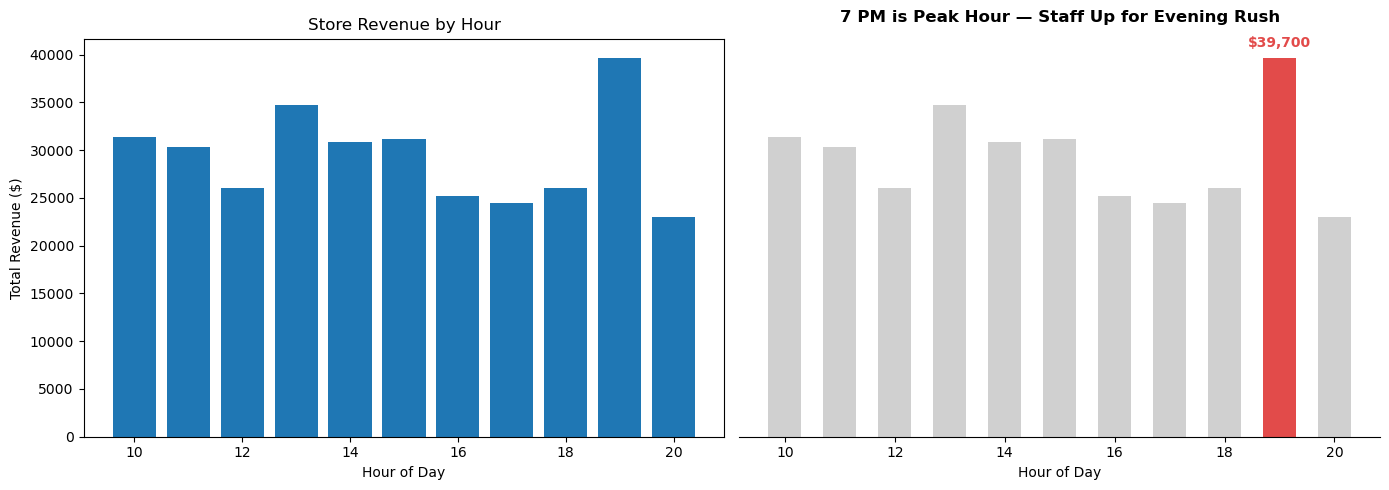

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# CSV Load karein
df = pd.read_csv('SuperMarket Analysis.csv')

# Columns ke name se extra spaces khatam karein


# df.columns.str.strip(): Column names ke aage ya peeche ki extra spaces (khali jagah)
# ko remove karta hai taaki KeyError na aaye.

df.columns = df.columns.str.strip()

# Check karein agar 'Total' column hai, nahi toh 'Sales' use karein
revenue_col = 'Total' if 'Total' in df.columns else 'Sales'  # Change 'Sales' to your actual column name if different


# Time column se Hour nikalein aur Revenue calculate karein



# pd.to_datetime(...).dt.hour: Time (jaise 19:30:00) ko convert karke sirf ghanta (19 yaani 7 PM) extract karta 
# hai aur ek naya column 'Hour' bana deta hai.

# df.groupby('Hour')[revenue_col].sum(): Har ghante ki total sales ko add (sum) karke aik summary series banata hai.



df['Hour'] = pd.to_datetime(df['Time']).dt.hour
data = df.groupby('Hour')[revenue_col].sum()

# Subplots setup



# Screen par ek hi line mein 2 charts (Side-by-side) ki jagah banata hai (1 row, 2 columns) 
# jiska size 14x5 inches hota hai.

# ax1: Pehla chart (Before)

# ax2: Doosra chart (After)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- BEFORE: Basic Chart ----

# Standard bar chart banata hai jisme sabhi bars ka color same blue hota hai.

# Normal title aur axis labels set karta hai.

    
ax1.bar(data.index, data.values)
ax1.set_title('Store Revenue by Hour')
ax1.set_ylabel('Total Revenue ($)')
ax1.set_xlabel('Hour of Day')

# ---- AFTER: Professional Redesign ----



# List comprehension ke zariye sab se zyada sales wale ghante (data.max()) ko Red 
#E24B4A) color deta hai, aur baki tamam bars ko Muted Gray (#D0D0D0) kar deta hai 
# taaki reader ka dhyan foran peak hour par jaye
    
colors = ['#E24B4A' if v == data.max() else '#D0D0D0' for v in data.values]

ax2.bar(data.index, data.values, color=colors, width=0.6)

# Insight Title
ax2.set_title('7 PM is Peak Hour — Staff Up for Evening Rush',
              fontsize=12, fontweight='bold', pad=12)


# Annotation for peak
# data.idxmax() se sab se peak wala hour dhoondta hai.

# ax2.annotate() us peak bar ke theek upar sales ki value (e.g. $12,450) red text mein likh
# deta hai taaki y-axis na dekhna pare.


peak_hour = data.idxmax()
ax2.annotate(f'${data.max():,.0f}',
             xy=(peak_hour, data.max()),
             xytext=(0, 8), textcoords='offset points',
             ha='center', fontweight='bold', color='#E24B4A')

# Declutter Spines & Y-axis

# Chart ki Top, Right aur Left borders (spines) aur Y-axis ko chupa (hide) deta hai taaki chart saaf aur minimalist dikhe.
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_visible(False)
ax2.set_xlabel('Hour of Day')

plt.tight_layout()
plt.savefig('supermarket_chart_makeover.png', dpi=200, bbox_inches='tight')
plt.show()

In [6]:
# BUIlding HTML REPort /etc

In [11]:

# Matplotlib se PdfPages class import kar rahe hain. Iska kaam multiple plots/charts ko ek hi PDF document
# ke alag alag pages par save karna hota hai.

from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import datetime

def add_footer(fig, page_num, total_pages):


# date_str = datetime.date.today().strftime('%B %Y'): Today's date se Month ka poora naam aur Year
    # (jaise July 2026) extract karta hai.

# fig.text(x, y, text, ...): Figure coordinate system (0 se 1 ke darmayan) par text positioning:

# 0.05, 0.02: Bottom Left corner par author ka naam aur title (Gauhar Ali Khan | Data Scientist).

# 0.5, 0.02: Bottom Center par current month aur year (date_str).

# 0.95, 0.02: Bottom Right corner par page counter (Page 1 of 3).

# ha='left' / 'center' / 'right': Text alignment control (Horizontal Alignment).    
    
    date_str = datetime.date.today().strftime('%B %Y')
    fig.text(0.05, 0.02, f'Gauhar Ali Khan | Data Scientist',
             ha='left', fontsize=8, color='gray')
    fig.text(0.5, 0.02, date_str,
             ha='center', fontsize=8, color='gray')
    fig.text(0.95, 0.02, f'Page {page_num} of {total_pages}',
             ha='right', fontsize=8, color='gray')


# with PdfPages('housing_analysis_report.pdf') as pdf:: housing_analysis_report.pdf naam ki file
# open hoti hai. with statement ensure karta hai ki execution ke baad PDF safe tareeqe
# se close aur save ho jaye.

with PdfPages('housing_analysis_report.pdf') as pdf:

    
 # Page 1: Title page
    
# figsize=(8.5, 11): Standard US Letter Paper Size (8.5 x 11 inches) ka blank page tayyar karta hai.
    
   fig1 = plt.figure(figsize=(8.5, 11))

    
#  0.5, 0.65: Page ke middle mein (50% horizontal) aur thoda upar (65% vertical).

# transform=fig1.transFigure: Text coordinates ko poore page canvas ke hisab se absolute positioning deta hai.

# fontsize=22, fontweight='bold': Bada aur bold title text 

    
    plt.text(0.5, 0.65, 'California Housing Price Analysis',
             ha='center', fontsize=22, fontweight='bold',
             transform=fig1.transFigure)
    plt.text(0.5, 0.55, 'Predictive Model & Market Intelligence Report',
             ha='center', fontsize=14, color='gray',
             transform=fig1.transFigure)
    
    # ---------------- FIXED HERE ----------------
    # Single quote (') ki jagah Triple quote (''') use kiya hai
    plt.text(0.5, 0.42,
             '''Key Finding: Median Income explains 52% of house price variation.

Tuned Random Forest achieves R² = 0.65 on unseen data.''',
             ha='center', fontsize=12, linespacing=1.8,
             transform=fig1.transFigure)
    # -------------------------------------------



# plt.axis('off'): Grid lines aur empty graph axes ko remove karta hai.

# add_footer(fig1, 1, 3): Footer add karta hai jisme Page 1 of 3 likha aata hai.

# pdf.savefig(fig1, bbox_inches='tight'): Page 1 ko PDF document ke andar push / save kar deta hai 
# (bbox_inches='tight' extra margin white space ko remove karta hai).

# plt.close(): Figure ko RAM memory se clear kar deta hai taaki next pages render karne ke liye
# memory heavy na ho.


    plt.axis('off')
    add_footer(fig1, 1, 3)
    pdf.savefig(fig1, bbox_inches='tight')
    plt.close()

    # Page 2 & 3: Your charts go here
    print("PDF saved: housing_analysis_report.pdf")

PDF saved: housing_analysis_report.pdf


In [12]:
# TASK 4    

In [13]:
# Case study template — use for every portfolio project

case_study_template = """
# [Project Title]

## The Problem
[One sentence: what was the client trying to solve?]
A telecom company was losing 16% of customers annually with no way to 
identify at-risk customers before they cancelled.

## My Approach
[2-3 sentences: what did you build and how?]
I built an end-to-end churn prediction pipeline using Random Forest 
classifier on 7,043 historical customer records. Feature engineering 
included encoding 10 categorical variables and scaling numerical features 
using a Scikit-learn Pipeline to prevent data leakage.

## Results
[Specific numbers only — no vague claims]
- Model AUC: 0.84 (vs 0.5 random baseline)
- Correctly identified 173 of 373 actual churners in test set
- Top predictor: Contract type (month-to-month = 3x higher churn risk)

## Business Impact
[The number the client cares about]
Identified the top 200 highest-risk customers representing $10,622 in 
monthly recurring revenue — enabling targeted retention intervention 
before cancellation.

## Tools Used
Python · Scikit-learn · Pandas · Streamlit · Random Forest · GridSearchCV

## Live Demo
[Streamlit URL if available]
"""
print(case_study_template)


# [Project Title]

## The Problem
[One sentence: what was the client trying to solve?]
A telecom company was losing 16% of customers annually with no way to 
identify at-risk customers before they cancelled.

## My Approach
[2-3 sentences: what did you build and how?]
I built an end-to-end churn prediction pipeline using Random Forest 
classifier on 7,043 historical customer records. Feature engineering 
included encoding 10 categorical variables and scaling numerical features 
using a Scikit-learn Pipeline to prevent data leakage.

## Results
[Specific numbers only — no vague claims]
- Model AUC: 0.84 (vs 0.5 random baseline)
- Correctly identified 173 of 373 actual churners in test set
- Top predictor: Contract type (month-to-month = 3x higher churn risk)

## Business Impact
[The number the client cares about]
Identified the top 200 highest-risk customers representing $10,622 in 
monthly recurring revenue — enabling targeted retention intervention 
before cancellation.

## Tools Use